### Section 1: Install Required Libraries and Load Dataset

**1.1: Install Required Libraries and Import Dependencies**

In [13]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN, MeanShift, AgglomerativeClustering
import hdbscan
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering
from sklearn.datasets import make_blobs

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


**1.2: Generate A Mock Dataset**

In [14]:
# Generate a mock dataset using make_blobs
n_samples = 500
n_features = 2
n_clusters = 4
random_state = 42

mock_data, mock_labels = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=n_clusters,
    cluster_std=1.0,
    random_state=random_state
)

### Section 2: Preprocess the Data

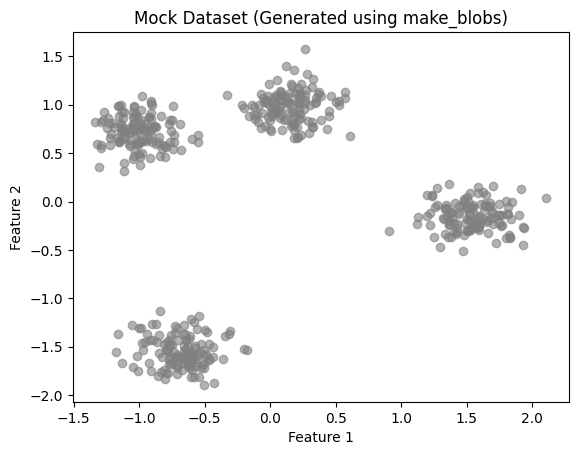

,Feature_1,Feature_2
0,-0.815393,0.589390
1,-1.173444,-1.553288
2,1.938811,-0.272989
3,0.092842,0.736467
4,-0.433975,-1.609212


In [15]:
# Normalize the features
scaler = StandardScaler()
mock_data_scaled = scaler.fit_transform(mock_data)

# Prepare the initial data for visualization and clustering algorithms
mock_df = pd.DataFrame(mock_data_scaled, columns=["Feature_1", "Feature_2"])

# Visualize the mock dataset
plt.scatter(mock_data_scaled[:, 0], mock_data_scaled[:, 1], c='gray', alpha=0.6)
plt.title("Mock Dataset (Generated using make_blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

mock_df.head()

### Section 3: Metrics And Visualizations

In [16]:
# Initialize results dictionary
results = {
    "Algorithm": [],
    "Silhouette Score": [],
    "Davies-Bouldin Index": [],
    "Calinski-Harabasz Score": []
}

# Function to compute and print clustering metrics
def compute_metrics(mock_data_scaled, labels, algorithm_name):
    silhouette = silhouette_score(mock_data_scaled, labels)
    davies_bouldin = davies_bouldin_score(mock_data_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(mock_data_scaled, labels)
    print(f"{algorithm_name} Metrics:")
    print(f"  Silhouette Score: {silhouette}")
    print(f"  Davies-Bouldin Score: {davies_bouldin}")
    print(f"  Calinski-Harabasz Score: {calinski_harabasz}")
    return silhouette, davies_bouldin, calinski_harabasz

# Function to visualize clustering using PCA
def visualize_clusters_pca(mock_data_scaled, labels, algorithm_name):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(mock_data_scaled)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(f"{algorithm_name} Clustering Visualization (PCA)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar()
    plt.show()

# Function to visualize clustering using t-SNE
def visualize_clusters_tsne(mock_data_scaled, labels, algorithm_name):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(mock_data_scaled)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(f"{algorithm_name} Clustering Visualization (t-SNE)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.colorbar()
    plt.show()

### Section 4: Clustering Algorithms And Compute Metrics & Visualize

**4.1: K-Means Clustering**

K-Means Metrics:
  Silhouette Score: 0.7466113868280718
  Davies-Bouldin Score: 0.36508140962345387
  Calinski-Harabasz Score: 1891.9758829246052


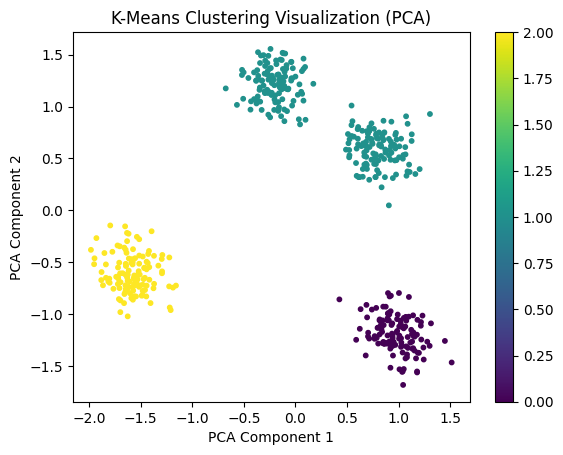

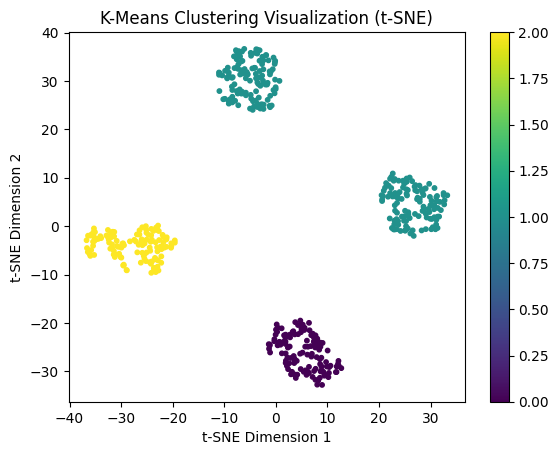

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(mock_data_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(mock_data_scaled, kmeans_labels, "K-Means")
visualize_clusters_pca(mock_data_scaled, kmeans_labels, "K-Means")
visualize_clusters_tsne(mock_data_scaled, kmeans_labels, "K-Means")

results["Algorithm"].append("K-Means")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.2: DBSCAN Clustering**

DBSCAN Metrics:
  Silhouette Score: 0.7466113868280718
  Davies-Bouldin Score: 0.36508140962345387
  Calinski-Harabasz Score: 1891.9758829246052


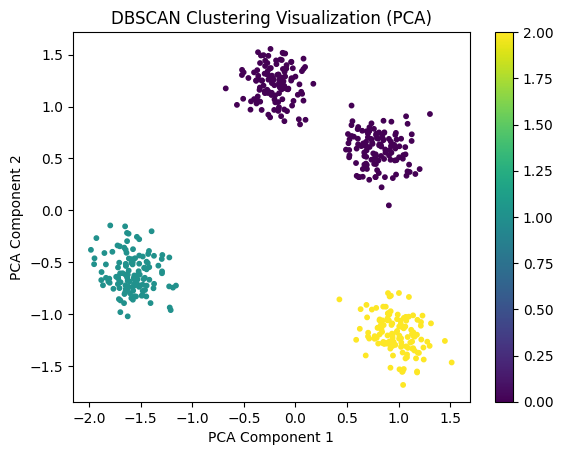

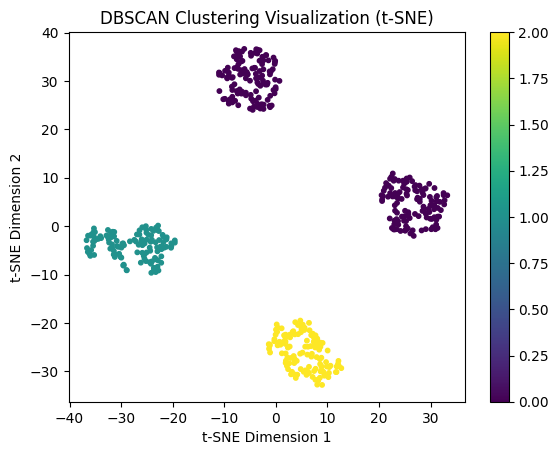

In [18]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(mock_data_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(mock_data_scaled, dbscan_labels, "DBSCAN")
visualize_clusters_pca(mock_data_scaled, dbscan_labels, "DBSCAN")
visualize_clusters_tsne(mock_data_scaled, dbscan_labels, "DBSCAN")

results["Algorithm"].append("DBSCAN")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.3: HDBSCAN Clustering**

HDBSCAN Metrics:
  Silhouette Score: 0.7979185955370356
  Davies-Bouldin Score: 0.281927966858884
  Calinski-Harabasz Score: 5578.01205863999


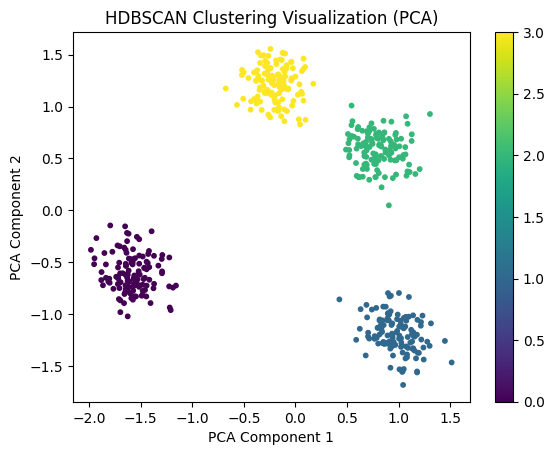

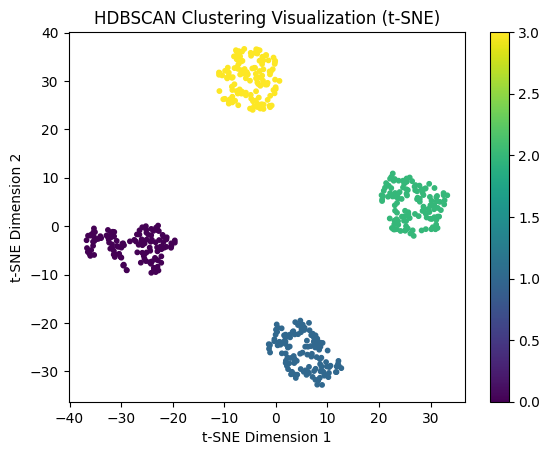

In [19]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=10)
hdbscan_labels = hdbscan_model.fit_predict(mock_data_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(mock_data_scaled, hdbscan_labels, "HDBSCAN")
visualize_clusters_pca(mock_data_scaled, hdbscan_labels, "HDBSCAN")
visualize_clusters_tsne(mock_data_scaled, hdbscan_labels, "HDBSCAN")

results["Algorithm"].append("HDBSCAN")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.4 Mean Shift Clustering**

Mean Shift Metrics:
  Silhouette Score: 0.5548427597640048
  Davies-Bouldin Score: 0.5922990605603107
  Calinski-Harabasz Score: 449.7662017595061


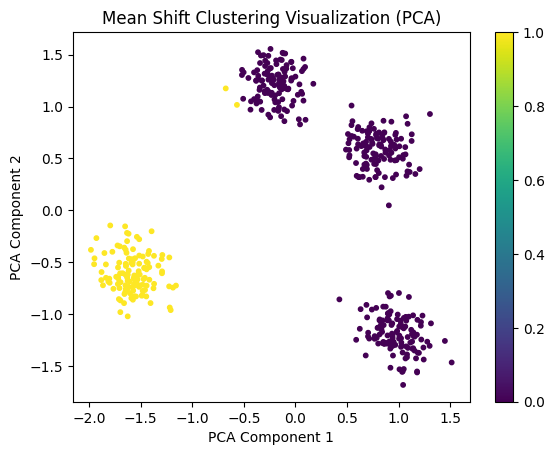

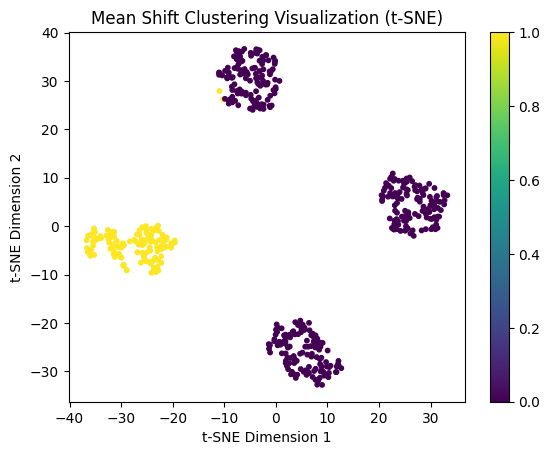

In [20]:
mean_shift = MeanShift()
mean_shift_labels = mean_shift.fit_predict(mock_data_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(mock_data_scaled, mean_shift_labels, "Mean Shift")
visualize_clusters_pca(mock_data_scaled, mean_shift_labels, "Mean Shift")
visualize_clusters_tsne(mock_data_scaled, mean_shift_labels, "Mean Shift")

results["Algorithm"].append("Mean Shift")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.5: Hierarchical Clustering**

Hierarchical Clustering Metrics:
  Silhouette Score: 0.7466113868280718
  Davies-Bouldin Score: 0.36508140962345387
  Calinski-Harabasz Score: 1891.9758829246052


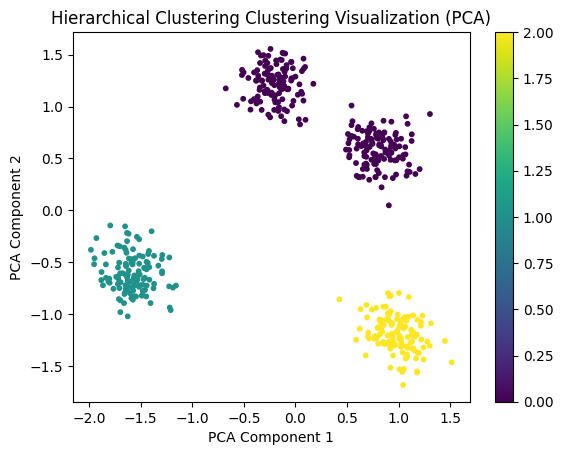

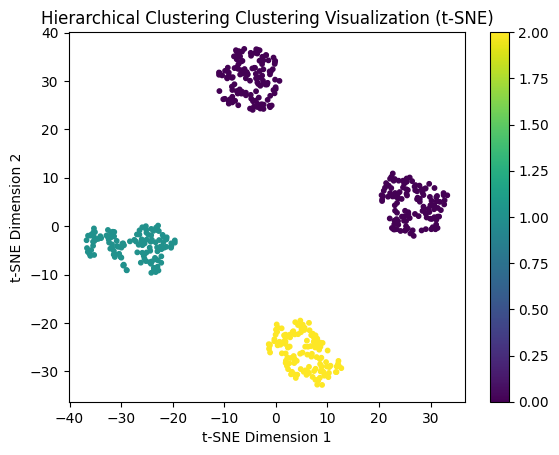

In [21]:
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(mock_data_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(mock_data_scaled, hierarchical_labels, "Hierarchical Clustering")
visualize_clusters_pca(mock_data_scaled, hierarchical_labels, "Hierarchical Clustering")
visualize_clusters_tsne(mock_data_scaled, hierarchical_labels, "Hierarchical Clustering")

results["Algorithm"].append("Hierarchical Clustering")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

**4.6: Spectral Clustering (Optional)**

Spectral Clustering Metrics:
  Silhouette Score: 0.40999904641864554
  Davies-Bouldin Score: 1.732298162021355
  Calinski-Harabasz Score: 268.5290470090516


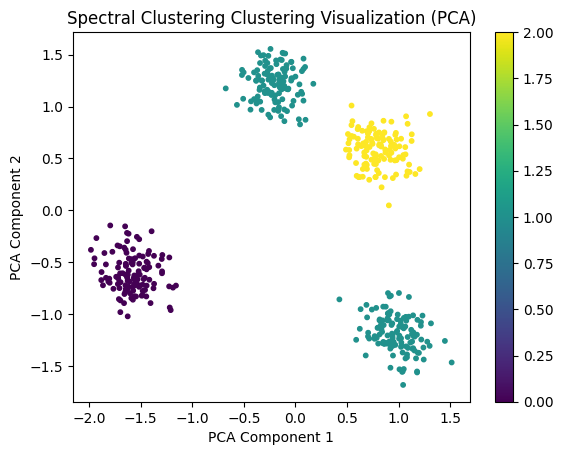

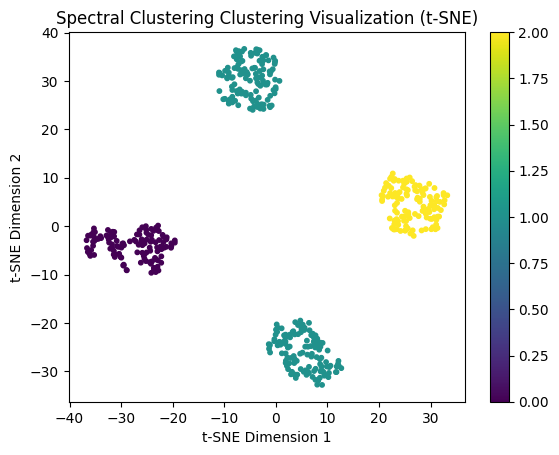

In [22]:
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
spectral_labels = spectral.fit_predict(mock_data_scaled)

# Compute metrics and visualize
silhouette, davies_bouldin, calinski_harabasz = compute_metrics(mock_data_scaled, spectral_labels, "Spectral Clustering")
visualize_clusters_pca(mock_data_scaled, spectral_labels, "Spectral Clustering")
visualize_clusters_tsne(mock_data_scaled, spectral_labels, "Spectral Clustering")

results["Algorithm"].append("Spectral Clustering")
results["Silhouette Score"].append(silhouette)
results["Davies-Bouldin Index"].append(davies_bouldin)
results["Calinski-Harabasz Score"].append(calinski_harabasz)

### Section 5: Comparison and Summary

In [23]:
# Convert results dictionary to DataFrame
comparison_df = pd.DataFrame(results)

# Display the results
print("Clustering Algorithm Comparison:")
print(comparison_df)

Clustering Algorithm Comparison:
                 Algorithm  Silhouette Score  Davies-Bouldin Index  \
0                  K-Means          0.746611              0.365081   
1                   DBSCAN          0.746611              0.365081   
2                  HDBSCAN          0.797919              0.281928   
3               Mean Shift          0.554843              0.592299   
4  Hierarchical Clustering          0.746611              0.365081   
5      Spectral Clustering          0.409999              1.732298   

   Calinski-Harabasz Score  
0              1891.975883  
1              1891.975883  
2              5578.012059  
3               449.766202  
4              1891.975883  
5               268.529047  
